C:\Users\Gordus_Lab\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


10


B:\TMP\ipykernel_31064\402629371.py:82: RuntimeWarning: divide by zero encountered in divide
  r = (1 / r) ** 2
B:\TMP\ipykernel_31064\402629371.py:83: RuntimeWarning: invalid value encountered in divide
  r = r / np.max(r)


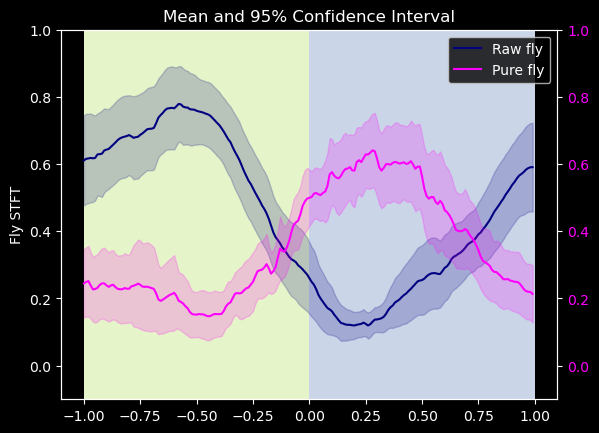

In [1]:
import numpy as np
import pandas as pd
import glob
import matplotlib
from sklearn import linear_model
from scipy.signal import hilbert
from scipy import signal

from scipy import stats
import matplotlib.pyplot as plt

#stimulus_window = 70  #stimulus length for STA (stimulus trigger ensembles average)
roll_time = 5  #rolling time for probility estimation of the outcome
states_label=[0,1,2]
v_smooth_window=2
lp_f = 25
accuracy_list=[]
accuracy_list2=[]
accuracy_list4=[]
states_linear_output=[]
states_linear_output2=[]
states_linear_output4=[]


for stimulus_window in range(10,11, 2):
    print(stimulus_window)
    prob_states_mul_lr=[]
    prob_states_lr = []
    prob_states_lr_2=[]
    prob_states_lr_4 = []
    v_x_all =[]
    v_y_all=[]
    for states in states_label:
        #initial_time = [569, 276, 99,184,1776,567,2435,226,1017]
        initial_time = [569, 276, 99,1776,  567, 2435,  141, 109, 204, 400, 377, 206, 170,177, 207, 169]
        #initial_time = [567]
        videodirectory = 'B:/HsinYi/GitHub/sensory_beh/'
        videoname = '*'
        sensory_dic = videodirectory+'sensory_auto/'
        sensory_roi_files = glob.glob(sensory_dic+ videoname+ '_roi_coordinates_side.npz')
        sensory_stft_files = glob.glob(sensory_dic+ videoname+ '_roi_stft_side.npz')

        labeled_beh = []
        observations = []
        stimulus =[]
        stimulus_all=[]
        stimulus_fly=[]
        stimulus_v_x = []
        stimulus_v_y = []
        stimulus_fly_all=[]
        stimulus_v_x_all = []
        stimulus_v_y_all = []
        observations_fly = []



        ### Step 2: Linear Output

        labeled_beh = []
        observations = []
        observations_fly = []

        linear_output_all=[]
        linear_output_all_fly = []
        linear_output_all_vx = []
        linear_output_all_vy = []
        for j in range(len(sensory_roi_files)):
            sensory_roi = np.load(sensory_roi_files[j])
            sensory_stft = np.load(sensory_stft_files[j])
            roi_fly_list = sensory_roi['roi_fly_list']
            roi_spider_list = sensory_roi['roi_spider_list']
            nframes = roi_fly_list.shape[0]
            ff_stft = sensory_stft['ff']
            f_spec_fly = sensory_stft['f_spec_fly']
            f_spec_fly_p = sensory_stft['f_spec_fly_p']
            f_spec_spider_p = sensory_stft['f_spec_spider_p']
            vid_name = sensory_roi_files[j].split('/sensory_auto\\')[1].split('_roi_coordinates_side.npz')[0]
            r = roi_spider_list[:, 1] + roi_spider_list[:, 3] / 2 - roi_fly_list[:, 1] - roi_fly_list[:, 3] / 2
            r = np.abs(r)
            r = r / ((roi_spider_list[:, 2] + roi_spider_list[:, 3])) / 2
            # r = r / np.min(r)
            r = (1 / r) ** 2
            r = r / np.max(r)
            r[np.where(r < 0.5)[0]] = 0.5
            # r = r + 0.5
            # r = r / np.max(r)
            x = roi_fly_list[:, 0] + roi_fly_list[:, 2] / 2
            v_x = x - np.roll(x, 1)
            v_x = v_x[1:len(v_x)]
            y = roi_fly_list[:, 1] + roi_fly_list[:, 3] / 2
            v_y = y - np.roll(y, 1)
            v_y = v_y[1:len(v_y)]
            v_x = hilbert(v_x)
            v_x = np.abs(v_x)
            v_y = hilbert(v_y)
            v_y = np.abs(v_y)

            ## Load beh
            # filenames = glob.glob(videodirectory+ 'wavelet/'+vid_name+ '*_croprotaligned01234_nonormalized_wavelet.npz')
            # csv_filenames = glob.glob(videodirectory+'merging_static/' + vid_name + '*_wavelet_timestep.csv')
            beh_hmm = np.load(
                glob.glob(videodirectory + 'sensory_auto/' + vid_name + '*_hmm_umap_filtered_predictedlabels.npy')[0]
            )

            ## Sensory
            test_divide = np.divide(f_spec_fly, f_spec_fly_p)
            # test_divide = np.mean(test_divide, axis=0)
            t = [i for i in range(int(40 / 2), (nframes - int(40 / 2)), 2)]
            # t= [i for i in range(4000, 6000, 10)]
            # if '0328' in sensory_roi_files[j]:
            #     t.append(5100)
            t = np.array(t)

            t3 = [i for i in range(0, initial_time[j], 1)]
            t3 = np.array(t3)
            yinterp3 = np.interp(t3, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp3_mean = np.mean(yinterp3)
            yinterp3_std = np.std(yinterp3)
            yinterp3fly = np.interp(t3, t, np.mean(f_spec_fly[0:13, ], axis=0))
            yinterp3fly_mean = np.mean(yinterp3fly)
            yinterp3fly_std = np.std(yinterp3fly)
            yinterp3spider = np.interp(t3, t, np.mean(f_spec_spider_p[0:13, ], axis=0))
            yinterp3spider_mean = np.mean(yinterp3spider)
            yinterp3spider_std = np.std(yinterp3spider)

            t2 = [i for i in range(initial_time[j], (len(beh_hmm) + initial_time[j]), 1)]
            # # t= [i for i in range(4000, 6000, 10)]
            t2 = np.array(t2)
            #
            yinterp = np.interp(t2, t, np.mean(test_divide[0:13, ], axis=0))
            yinterp = (yinterp - yinterp3_mean) / yinterp3_std
            yinterpspider = np.interp(t2, t, np.mean(f_spec_spider_p[0:13, ], axis=0))
            #yinterpspider = (yinterpspider - yinterp3spider_mean) / yinterp3spider_std
            yinterpspider= yinterpspider / (np.max(yinterpspider))
            # yinterp = yinterp/(np.max(yinterp))
            # yinterp = interp1d(t,  test_divide, axis=1)
            # yinterp = yinterp(t2)
            yinterpfly = np.interp(t2, t, np.mean(f_spec_fly[0:13, :], axis=0))
            #yinterpfly = (yinterpfly - yinterp3fly_mean) / yinterp3fly_std
            # yinterpfly = yinterpfly/(np.max(yinterpfly))
            # yinterpfly = yinterpfly - yinterpspider * r[t2]
            yinterpfly = (yinterpfly - yinterp3fly_mean) / yinterp3fly_std

            v_x_sensory = v_x[t2][0:len(v_x[t2])]
            v_y_sensory = v_y[t2][0:len(v_y[t2])]

            sos = signal.butter(10, lp_f, 'lp', fs=100, output='sos')
            v_x_sensory = signal.sosfilt(sos, v_x_sensory)
            v_y_sensory = signal.sosfilt(sos, v_y_sensory)
            # for v_time in range(len(v_x_sensory)):
            #     if v_time < int(v_smooth_window / 2):
            #         v_x_sensory[v_time] = np.max(v_x_sensory[0: int(v_smooth_window)])
            #         v_y_sensory[v_time] = np.max(v_y_sensory[0: int(v_smooth_window)])
            #     else:
            #         v_x_sensory[v_time] = np.max(
            #             v_x_sensory[v_time - int(v_smooth_window / 2): v_time + int(v_smooth_window / 2)])
            #         v_y_sensory[v_time] = np.max(
            #             v_y_sensory[v_time - int(v_smooth_window / 2): v_time + int(v_smooth_window / 2)])

            linear_output=[]
            linear_output_fly=[]
            linear_output_v_x=[]
            linear_output_v_y=[]

            linear_output = np.array(yinterp)
            linear_output_fly = np.array(yinterpfly)
            linear_output_v_x = np.array(v_x_sensory)
            linear_output_v_y = np.array(v_y_sensory)
            linear_output_all.append(linear_output)
            linear_output_all_fly.append(linear_output_fly)
            linear_output_all_vx.append(linear_output_v_x)
            linear_output_all_vy.append(linear_output_v_y)
            labeled_beh.append(beh_hmm)

        linear_output_extend=[]
        linear_output_fly_extend = []
        linear_output_vx_extend = []
        linear_output_vy_extend = []
        labeled_beh_extend=[]
        for i in range(len(linear_output_all)):
            linear_output_extend.extend(linear_output_all[i])
            linear_output_fly_extend.extend(linear_output_all_fly[i])
            linear_output_vx_extend.extend(linear_output_all_vx[i])
            linear_output_vy_extend.extend(linear_output_all_vy[i])
            labeled_beh_extend.extend(labeled_beh[i])


import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap
plt.style.use('dark_background')
rainbow = get_cmap('Pastel2', 256)
newcolors = rainbow(np.linspace(0, 1, 8))
newcolors= np.delete(newcolors, 0, 0)
newcolors= np.delete(newcolors, 2, 0)
newcolors= np.delete(newcolors, [3,4,5], 0)
newcolors = np.roll(newcolors, -1, 0)
tab10 = get_cmap('tab10', 256)
ntabl10 = tab10(np.linspace(0, 1,10))
##### STFT Crouching to Static

from itertools import groupby
import numpy as np

extract_static_pull_fly_v2 = []
extract_static_pull_purefly_v2 = []

for i in range(len(labeled_beh)):
    beh = labeled_beh[i]
    linear_fly = linear_output_all_fly[i]
    linear_purefly = linear_output_all[i]

    # Grouping behavior states into blocks
    grouped = [sum(1 for _ in g) for k, g in groupby(beh)]
    labels = [k for k, g in groupby(beh)]
    cumsum = np.cumsum(grouped)
    state1=1
    state2=0
    start_idx = 0
    for j in range(1, len(cumsum)):
        if labels[j-1] == state1 and labels[j] == state2:
            idx1 = start_idx
            idx2 = cumsum[j]
            segment_beh = beh[idx1:idx2]

            # Get the first index of state 0 within this chunk
            try:
                state_2_start = np.where(np.array(segment_beh) == state2)[0][0]
            except IndexError:
                continue  # skip if no state 0 found (shouldn't happen but just in case)

            anchor = idx1 + state_2_start  # absolute index in original sequence

            # Create NaN-filled segments for both spider and fly
            seg_fly = np.full((200,), np.nan)
            seg_purefly = np.full((200,), np.nan)

            win_start = anchor - 100
            win_end = anchor + 100

            valid_start = max(win_start, 0)
            valid_end = min(win_end, len(beh))

            seg_start = valid_start - win_start
            seg_end = seg_start + (valid_end - valid_start)

            seg_fly[seg_start:seg_end] = linear_fly[valid_start:valid_end]
            seg_purefly[seg_start:seg_end] = linear_purefly[valid_start:valid_end]

            extract_static_pull_fly_v2.append(seg_fly)
            extract_static_pull_purefly_v2.append(seg_purefly)

        start_idx = cumsum[j-1]


trans_output = np.array(extract_static_pull_purefly_v2)
trans_output_fly = np.array(extract_static_pull_fly_v2)

for i in range(len(trans_output)):
    # plt.plot((extract_static_pull_fly[i] - np.nanmin(extract_static_pull_fly[i])) / (
    #             np.nanmax(extract_static_pull_fly[i]) - np.nanmin(extract_static_pull_fly[i])))
    trans_output[i]= (trans_output[i] - np.nanmin(trans_output[i])) / (
                np.nanmax(trans_output[i]) - np.nanmin(trans_output[i]))

for i in range(len(trans_output_fly)):
    trans_output_fly[i]= (trans_output_fly[i] - np.nanmin(trans_output_fly[i])) / (
                np.nanmax(trans_output_fly[i]) - np.nanmin(trans_output_fly[i]))
array = np.array(trans_output_fly)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-1,1, 0.01)  # Create an array of x values corresponding to the number of columns
fig, ax1 = plt.subplots()
# Plot the mean values
lns1=ax1.plot(x, mean, label='Raw fly', color='navy')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='navy', alpha=0.2,  zorder=1)


ax2 = ax1.twinx()
array = np.array(trans_output)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
lns2=ax2.plot(x, mean, label='Pure fly', color='magenta')
# Plot the confidence intervals
ax2.fill_between(x, ci_lower, ci_upper, color='magenta', alpha=0.2,  zorder=1)
ax2.tick_params(axis='y', labelcolor='magenta')
ax1.set_ylim([-0.1,1])
ax2.set_ylim([-0.1,1])
ax1.axvspan(-1, 0, ymin=0, ymax = 1, facecolor=newcolors[state1], alpha=1, zorder=-1)
ax1.axvspan(0, 1, ymin=0, ymax = 1, facecolor=newcolors[state2], alpha=1, zorder=-1)
# Add labels and title
plt.xlabel('Time (s)')
ax1.set_ylabel('Fly STFT')
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)
plt.title('Mean and 95% Confidence Interval')
# Show the plot
plt.show()

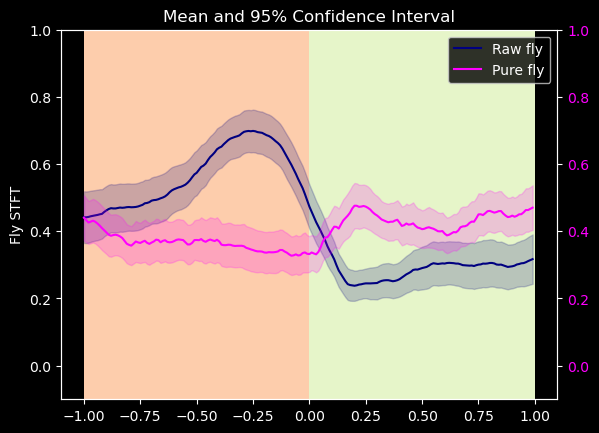

In [2]:

extract_static_pull_fly_v2 = []
extract_static_pull_purefly_v2 = []

for i in range(len(labeled_beh)):
    beh = labeled_beh[i]
    linear_fly = linear_output_all_fly[i]
    linear_purefly = linear_output_all[i]

    # Grouping behavior states into blocks
    grouped = [sum(1 for _ in g) for k, g in groupby(beh)]
    labels = [k for k, g in groupby(beh)]
    cumsum = np.cumsum(grouped)
    state1=2
    state2=1
    start_idx = 0
    for j in range(1, len(cumsum)):
        if labels[j-1] == state1 and labels[j] == state2:
            idx1 = start_idx
            idx2 = cumsum[j]
            segment_beh = beh[idx1:idx2]

  
            try:
                state_2_start = np.where(np.array(segment_beh) == state2)[0][0]
            except IndexError:
                continue  

            anchor = idx1 + state_2_start  # absolute index in original sequence

            # Create NaN-filled segments for both spider and fly
            seg_fly = np.full((200,), np.nan)
            seg_purefly = np.full((200,), np.nan)

            win_start = anchor - 100
            win_end = anchor + 100

            valid_start = max(win_start, 0)
            valid_end = min(win_end, len(beh))

            seg_start = valid_start - win_start
            seg_end = seg_start + (valid_end - valid_start)

            seg_fly[seg_start:seg_end] = linear_fly[valid_start:valid_end]
            seg_purefly[seg_start:seg_end] = linear_purefly[valid_start:valid_end]

            extract_static_pull_fly_v2.append(seg_fly)
            extract_static_pull_purefly_v2.append(seg_purefly)

        start_idx = cumsum[j-1]


trans_output = np.array(extract_static_pull_purefly_v2)
trans_output_fly = np.array(extract_static_pull_fly_v2)

for i in range(len(trans_output)):
    # plt.plot((extract_static_pull_fly[i] - np.nanmin(extract_static_pull_fly[i])) / (
    #             np.nanmax(extract_static_pull_fly[i]) - np.nanmin(extract_static_pull_fly[i])))
    trans_output[i]= (trans_output[i] - np.nanmin(trans_output[i])) / (
                np.nanmax(trans_output[i]) - np.nanmin(trans_output[i]))

for i in range(len(trans_output_fly)):
    trans_output_fly[i]= (trans_output_fly[i] - np.nanmin(trans_output_fly[i])) / (
                np.nanmax(trans_output_fly[i]) - np.nanmin(trans_output_fly[i]))
array = np.array(trans_output_fly)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
# Plotting
x = np.arange(-1,1, 0.01)  # Create an array of x values corresponding to the number of columns
fig, ax1 = plt.subplots()
# Plot the mean values
lns1=ax1.plot(x, mean, label='Raw fly', color='navy')
# Plot the confidence intervals
ax1.fill_between(x, ci_lower, ci_upper, color='navy', alpha=0.2,  zorder=1)


ax2 = ax1.twinx()
array = np.array(trans_output)
# Calculate the mean while ignoring NaNs
mean = np.nanmean(array, axis=0)
# Calculate the standard error of the mean while ignoring NaNs
n = np.sum(~np.isnan(array), axis=0)  # Number of non-NaN elements along the axis
stderr = np.nanstd(array, axis=0) / np.sqrt(n)
# Calculate the 95% confidence interval
confidence_level = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=mean, scale=stderr)
# Separate the lower and upper bounds of the confidence interval
ci_lower, ci_upper = confidence_interval
lns2=ax2.plot(x, mean, label='Pure fly', color='magenta')
# Plot the confidence intervals
ax2.fill_between(x, ci_lower, ci_upper, color='magenta', alpha=0.2,  zorder=1)
ax2.tick_params(axis='y', labelcolor='magenta')
ax1.set_ylim([-0.1,1])
ax2.set_ylim([-0.1,1])
ax1.axvspan(-1, 0, ymin=0, ymax = 1, facecolor=newcolors[state1], alpha=1, zorder=-1)
ax1.axvspan(0, 1, ymin=0, ymax = 1, facecolor=newcolors[state2], alpha=1, zorder=-1)
# Add labels and title
plt.xlabel('Time (s)')
ax1.set_ylabel('Fly STFT')
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)
plt.title('Mean and 95% Confidence Interval')
# Show the plot
plt.show()

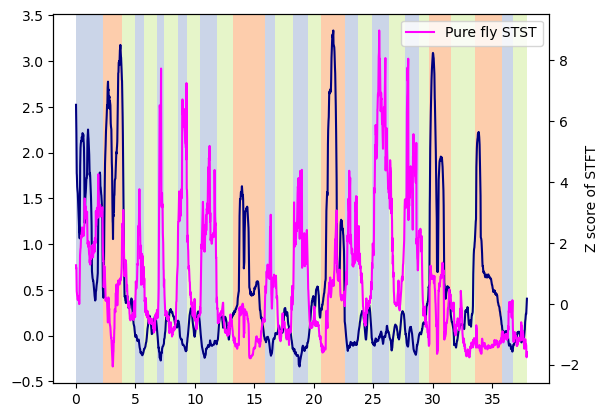

In [3]:


def plot_state_predict_as_color(x_data, state_data_predict, axis, newcolors, add_labels=True):
    state_current_predict = state_data_predict[0]
    span_left_predict = x_data[0]
    state_encountered_predict = []
    for span_right_predict, state_next_predict in zip(x_data, state_data_predict):
        if np.isnan(state_current_predict):
            state_current_predict = state_next_predict
            continue
        elif state_current_predict != state_next_predict:
            label = None
            if state_current_predict not in state_encountered_predict:
                state_encountered_predict.append(state_current_predict)
                if add_labels:
                    label = state_current_predict

            # plot section
            color = int(state_current_predict)
            axis.axvspan(span_left_predict, span_right_predict, ymin=0, ymax=1, facecolor=newcolors[color], alpha=1,
                         label=label)

            # Update current state parameters
            span_left_predict = span_right_predict
            state_current_predict = state_next_predict

beh_hmm_manual = np.load(
   'B:\HsinYi\DeepLabCut_Anthony\8videos_1400frames_relabled/videos/newvideo_allprey/aligned\wavelet/032122 Spider Prey-03212022154120-0000-1_croprotaligned01234_nonormalized_wavelet_manuallabels.npy')
beh_hmm_manual = beh_hmm_manual.astype(int)

plot_idx = np.arange(0,len(beh_hmm_manual))

beh_hmm_manual[-1]=0
df2 = np.array(beh_hmm_manual).astype(int)
plt.style.use('default')
fig, ax1 = plt.subplots()
lns1=ax1.plot(linear_output_all_fly[4], color = 'navy', label = 'Raw fly STFT')

ax2 = ax1.twinx()

lns2=ax2.plot(linear_output_all[4], color = 'magenta', label = 'Pure fly STST')

plt.legend(loc='upper right')
plt.xticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500], [0, 5, 10, 15, 20, 25, 30, 35])
plt.xlabel('Time (s)')
plt.ylabel('Z score of STFT')
ax2=plt.subplot()
plot_state_predict_as_color(x_data=plot_idx, state_data_predict = df2, newcolors=newcolors, axis=ax2)
plt.savefig('0321_pure_raw.svg')

Found 11 static epochs.
Kruskal–Wallis test: H=706.882, p=2.0920e-145
Static 1 vs Static 2: raw p=1.000e+00, Bonferroni-corrected p=1.000e+00
Static 1 vs Static 3: raw p=5.577e-03, Bonferroni-corrected p=3.067e-01
Static 1 vs Static 4: raw p=7.129e-29, Bonferroni-corrected p=3.921e-27
Static 1 vs Static 5: raw p=4.020e-03, Bonferroni-corrected p=2.211e-01
Static 1 vs Static 6: raw p=1.000e+00, Bonferroni-corrected p=1.000e+00
Static 1 vs Static 7: raw p=1.081e-01, Bonferroni-corrected p=1.000e+00
Static 1 vs Static 8: raw p=8.840e-01, Bonferroni-corrected p=1.000e+00
Static 1 vs Static 9: raw p=6.174e-39, Bonferroni-corrected p=3.396e-37
Static 1 vs Static 10: raw p=1.056e-28, Bonferroni-corrected p=5.808e-27
Static 1 vs Static 11: raw p=1.000e+00, Bonferroni-corrected p=1.000e+00
Static 2 vs Static 3: raw p=1.720e-04, Bonferroni-corrected p=9.460e-03
Static 2 vs Static 4: raw p=1.928e-23, Bonferroni-corrected p=1.060e-21
Static 2 vs Static 5: raw p=1.069e-10, Bonferroni-corrected p=5.

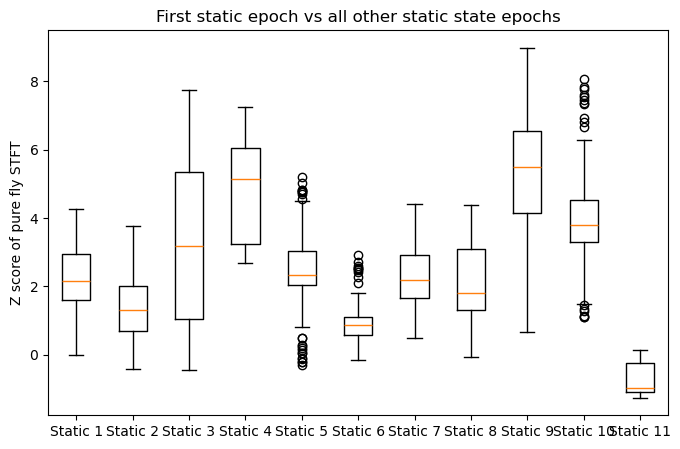

In [50]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import itertools

# --- Assume these exist ---
signal = np.array(linear_output_all[4])
behavior = np.array(beh_hmm_manual)

# --- 1. Find static epochs ---
static_mask = behavior == 0
static_indices = np.where(static_mask)[0]
static_epochs = np.split(static_indices, np.where(np.diff(static_indices) != 1)[0] + 1)

# --- 2. Collect signals for each static epoch ---
static_signals = [signal[epoch] for epoch in static_epochs if len(epoch) > 10]
print(f"Found {len(static_signals)} static epochs.")

# --- 3. Kruskal–Wallis across all epochs ---
H, p_value = stats.kruskal(*static_signals)
print(f"Kruskal–Wallis test: H={H:.3f}, p={p_value:.4e}")

# --- 4. Pairwise Mann–Whitney with Bonferroni correction ---
pairs = list(itertools.combinations(range(len(static_signals)), 2))
results = []
for i, j in pairs:
    stat, p = stats.mannwhitneyu(static_signals[i], static_signals[j], alternative="less")
    results.append((i, j, p))

# Bonferroni correction
p_values = np.array([r[2] for r in results])
p_bonf = np.minimum(p_values * len(p_values), 1.0)

for (i, j, p), pb in zip(results, p_bonf):
    print(f"Static {i+1} vs Static {j+1}: raw p={p:.3e}, Bonferroni-corrected p={pb:.3e}")

# --- 5. Plot each static epoch’s amplitude distribution ---
plt.figure(figsize=(8,5))
plt.boxplot(static_signals, labels=[f"Static {i+1}" for i in range(len(static_signals))])
plt.ylabel("Z score of pure fly STFT")
plt.title("First static epoch vs all other static state epochs")

plt.savefig('epoch_1.svg')

First static epoch length: 226
Found 12 state 1 epochs
First static vs State 1 epoch 1: U=22156.000, p=1.2993e-28
First static vs State 1 epoch 2: U=24967.000, p=9.9278e-50
First static vs State 1 epoch 3: U=25978.000, p=3.0004e-46
First static vs State 1 epoch 4: U=22529.000, p=8.5592e-32
First static vs State 1 epoch 5: U=30731.000, p=1.8942e-57
First static vs State 1 epoch 6: U=33562.000, p=2.5827e-57
First static vs State 1 epoch 7: U=24232.000, p=2.1603e-48
First static vs State 1 epoch 8: U=24181.000, p=1.2299e-36
First static vs State 1 epoch 9: U=21357.000, p=1.5490e-12
First static vs State 1 epoch 10: U=16341.000, p=5.6698e-20
First static vs State 1 epoch 11: U=46425.000, p=1.2418e-71
First static vs State 1 epoch 12: U=26668.000, p=1.1607e-52


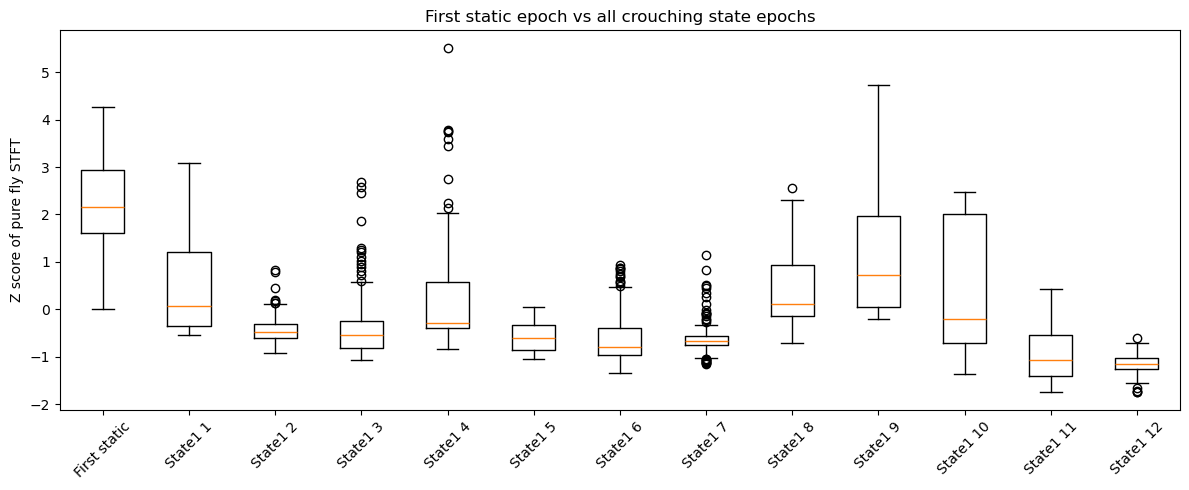

In [51]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- Assume these exist ---
signal = np.array(linear_output_all[4])
behavior = np.array(beh_hmm_manual)

# --- 1. Extract first static epoch ---
static_mask = behavior == 0
static_indices = np.where(static_mask)[0]
static_epochs = np.split(static_indices, np.where(np.diff(static_indices) != 1)[0] + 1)
static_signals = [signal[epoch] for epoch in static_epochs if len(epoch) > 10]

first_static = static_signals[0]  # first static epoch
print(f"First static epoch length: {len(first_static)}")

# --- 2. Extract all state 1 epochs ---
state1_mask = behavior == 1
state1_indices = np.where(state1_mask)[0]
state1_epochs = np.split(state1_indices, np.where(np.diff(state1_indices) != 1)[0] + 1)
state1_signals = [signal[epoch] for epoch in state1_epochs if len(epoch) > 10]

print(f"Found {len(state1_signals)} state 1 epochs")

# --- 3. Mann–Whitney U test: first static vs each state 1 epoch ---
p_values = []
for i, epoch in enumerate(state1_signals):
    stat, p = stats.mannwhitneyu(first_static, epoch, alternative="greater")
    p_values.append(p)
    print(f"First static vs State 1 epoch {i+1}: U={stat:.3f}, p={p:.4e}")

# --- 4. Visualization ---
plt.figure(figsize=(12,5))
plt.boxplot([first_static] + state1_signals, 
            labels=["First static"] + [f"State1 {i+1}" for i in range(len(state1_signals))])
plt.ylabel("Z score of pure fly STFT")
plt.title("First static epoch vs all crouching state epochs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('epoch_2.svg')


First static epoch length: 226
Found 5 state 1 epochs
First static vs State 1 epoch 1: U=33684.000, p=8.5992e-50
First static vs State 1 epoch 2: U=60115.000, p=7.7589e-82
First static vs State 1 epoch 3: U=40492.000, p=1.2345e-44
First static vs State 1 epoch 4: U=37800.000, p=2.8239e-50
First static vs State 1 epoch 5: U=50398.000, p=2.4032e-75


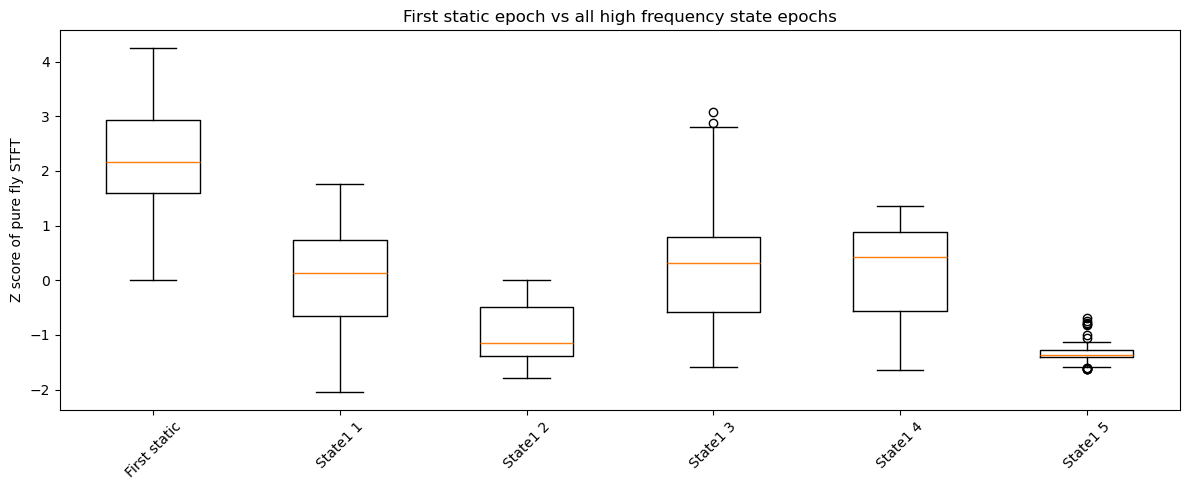

In [53]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# --- Assume these exist ---
signal = np.array(linear_output_all[4])
behavior = np.array(beh_hmm_manual)

# --- 1. Extract first static epoch ---
static_mask = behavior == 0
static_indices = np.where(static_mask)[0]
static_epochs = np.split(static_indices, np.where(np.diff(static_indices) != 1)[0] + 1)
static_signals = [signal[epoch] for epoch in static_epochs if len(epoch) > 10]

first_static = static_signals[0]  # first static epoch
print(f"First static epoch length: {len(first_static)}")

# --- 2. Extract all state 1 epochs ---
state1_mask = behavior == 2
state1_indices = np.where(state1_mask)[0]
state1_epochs = np.split(state1_indices, np.where(np.diff(state1_indices) != 1)[0] + 1)
state1_signals = [signal[epoch] for epoch in state1_epochs if len(epoch) > 10]

print(f"Found {len(state1_signals)} state 1 epochs")

# --- 3. Mann–Whitney U test: first static vs each state 1 epoch ---
p_values = []
for i, epoch in enumerate(state1_signals):
    stat, p = stats.mannwhitneyu(first_static, epoch, alternative="greater")
    p_values.append(p)
    print(f"First static vs State 1 epoch {i+1}: U={stat:.3f}, p={p:.4e}")

# --- 4. Visualization ---
plt.figure(figsize=(12,5))
plt.boxplot([first_static] + state1_signals, 
            labels=["First static"] + [f"State1 {i+1}" for i in range(len(state1_signals))])
plt.ylabel("Z score of pure fly STFT")
plt.title("First static epoch vs all high frequency state epochs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('epoch_3.svg')
